In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

data = [
    {'device': 'IDx-DR', 'intended_purpose': 'diagnosis', 'physical_harm_severity': 'minor', "clinical_decision_severity": "severe",
     'autonomy_level': 'fully_autonomous', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': 'Class II', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'mechanistic/feature-based architecture, not end-to-end black-box; algorithm locked (non-adaptive)'},

    {'device': 'Da Vinci Surgical System', 'intended_purpose': 'treatment', 'physical_harm_severity': 'high', "clinical_decision_severity": "catastrophic",
     'autonomy_level': 'human_in_loop', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'sole_source', 'fda_class': 'Class II', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Surgeon-controlled robotic system; mechanical/transparent operation; high reliance on surgeon input'},

    {'device': 'Medtronic MiniMed 670G', 'intended_purpose': 'treatment', 'physical_harm_severity': 'high', "clinical_decision_severity": "catastrophic",
     'autonomy_level': 'decision_support', 'explainability': 'transparent', 'is_adaptive': 'yes',
     'reliance': 'sole_source', 'fda_class': 'Class III', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Hybrid closed-loop (basal automated, meal bolus manual = human-on-the-loop); Auto Mode adapts to patient patterns over time'},

    {'device': 'Viz.ai', 'intended_purpose': 'diagnosis', 'physical_harm_severity': 'minor', "clinical_decision_severity": "severe",
     'autonomy_level': 'human_in_loop', 'explainability': 'black_box', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': 'Class II', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Semi-explainable CNN; alerts clinician, does not act autonomously'},

    {'device': 'AliveCor KardiaMobile', 'intended_purpose': 'diagnosis', 'physical_harm_severity': 'minor', "clinical_decision_severity": "moderate",
     'autonomy_level': 'human_in_loop', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': 'Class II', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Explainable hybrid detection mode; personal ECG screening, not sole diagnostic source'},

    {'device': 'PathAI', 'intended_purpose': 'diagnosis', 'physical_harm_severity': 'no_harm', "clinical_decision_severity": "severe",
     'autonomy_level': 'human_in_loop', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': 'Class II', 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Visual/explainable output highlighting regions of interest; pathologist reviews and decides'},

    {'device': 'Sepsis Early-Warning System (EHR)', 'intended_purpose': 'prediction', 'physical_harm_severity': 'no_harm ', "clinical_decision_severity": "severe",
     'autonomy_level': 'decision_support', 'explainability': 'black_box', 'is_adaptive': 'yes',
     'reliance': 'supporting_tool', 'fda_class': "None", 'eu_ai_risk_category': 'High-Risk',
     'notes': 'Hypothetical/illustrative example, not a specific named product'},

    {'device': 'Radiology Triage Tool', 'intended_purpose': 'prediction', 'physical_harm_severity': 'minor', "clinical_decision_severity": "moderate",
     'autonomy_level': 'decision_support', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': "None", 'eu_ai_risk_category': 'Limited-Risk',
     'notes': 'Hypothetical/illustrative example'},

    {'device': 'Symptom Checker Chatbot', 'intended_purpose': 'prevention', 'physical_harm_severity': 'no_harm', "clinical_decision_severity": "minor",
     'autonomy_level': 'decision_support', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': "None", 'eu_ai_risk_category': 'Limited-Risk',
     'notes': 'Hypothetical/illustrative example'},

    {'device': 'Medication Reminder App', 'intended_purpose': 'administrative', 'physical_harm_severity': 'no_harm', "clinical_decision_severity": "minor",
     'autonomy_level': 'human_in_loop', 'explainability': 'transparent', 'is_adaptive': 'no',
     'reliance': 'supporting_tool', 'fda_class': "None", 'eu_ai_risk_category': 'Minimal-Risk',
     'notes': 'Hypothetical/illustrative example'},
]

df_project = pd.DataFrame(data)
df_project


,device,intended_purpose,physical_harm_severity,clinical_decision_severity,autonomy_level,explainability,is_adaptive,reliance,fda_class,eu_ai_risk_category,notes
0,IDx-DR,diagnosis,minor,severe,fully_autonomous,transparent,no,supporting_tool,Class II,High-Risk,"mechanistic/feature-based architecture, not en..."
1,Da Vinci Surgical System,treatment,high,catastrophic,human_in_loop,transparent,no,sole_source,Class II,High-Risk,Surgeon-controlled robotic system; mechanical/...
2,Medtronic MiniMed 670G,treatment,high,catastrophic,decision_support,transparent,yes,sole_source,Class III,High-Risk,"Hybrid closed-loop (basal automated, meal bolu..."
3,Viz.ai,diagnosis,minor,severe,human_in_loop,black_box,no,supporting_tool,Class II,High-Risk,"Semi-explainable CNN; alerts clinician, does n..."
4,AliveCor KardiaMobile,diagnosis,minor,moderate,human_in_loop,transparent,no,supporting_tool,Class II,High-Risk,Explainable hybrid detection mode; personal EC...
5,PathAI,diagnosis,no_harm,severe,human_in_loop,transparent,no,supporting_tool,Class II,High-Risk,Visual/explainable output highlighting regions...
6,Sepsis Early-Warning System (EHR),prediction,no_harm,severe,decision_support,black_box,yes,supporting_tool,None,High-Risk,"Hypothetical/illustrative example, not a speci..."
7,Radiology Triage Tool,prediction,minor,moderate,decision_support,transparent,no,supporting_tool,None,Limited-Risk,Hypothetical/illustrative example
8,Symptom Checker Chatbot,prevention,no_harm,minor,decision_support,transparent,no,supporting_tool,None,Limited-Risk,Hypothetical/illustrative example
9,Medication Reminder App,administrative,no_harm,minor,human_in_loop,transparent,no,supporting_tool,None,Minimal-Risk,Hypothetical/illustrative example


In [3]:
# Ordinal Encoding 
df_project['physical_harm_severity'] = df_project['physical_harm_severity'].map(
    {'no_harm': 0, 'minor': 1, 'high': 2})
df_project['clinical_decision_severity'] = df_project['clinical_decision_severity'].map(
    {'minor': 0, 'moderate': 1, 'severe': 2, 'catastrophic': 3})

# Binary Label Encoding
df_project['explainability'] = df_project['explainability'].map({'transparent': 0, 'black_box': 1})
df_project['is_adaptive'] = df_project['is_adaptive'].map({'no': 0, 'yes': 1})
df_project['reliance'] = df_project['reliance'].map({'supporting_tool': 0, 'sole_source': 1})

# One-Hot Encoding
df_project_encoded = pd.get_dummies(df_project, columns=['intended_purpose', 'autonomy_level'], drop_first=True)

df_project_encoded


,device,physical_harm_severity,clinical_decision_severity,explainability,is_adaptive,reliance,fda_class,eu_ai_risk_category,notes,intended_purpose_diagnosis,intended_purpose_prediction,intended_purpose_prevention,intended_purpose_treatment,autonomy_level_fully_autonomous,autonomy_level_human_in_loop
0,IDx-DR,1.0,2,0,0,0,Class II,High-Risk,"mechanistic/feature-based architecture, not en...",True,False,False,False,True,False
1,Da Vinci Surgical System,2.0,3,0,0,1,Class II,High-Risk,Surgeon-controlled robotic system; mechanical/...,False,False,False,True,False,True
2,Medtronic MiniMed 670G,2.0,3,0,1,1,Class III,High-Risk,"Hybrid closed-loop (basal automated, meal bolu...",False,False,False,True,False,False
3,Viz.ai,1.0,2,1,0,0,Class II,High-Risk,"Semi-explainable CNN; alerts clinician, does n...",True,False,False,False,False,True
4,AliveCor KardiaMobile,1.0,1,0,0,0,Class II,High-Risk,Explainable hybrid detection mode; personal EC...,True,False,False,False,False,True
5,PathAI,0.0,2,0,0,0,Class II,High-Risk,Visual/explainable output highlighting regions...,True,False,False,False,False,True
6,Sepsis Early-Warning System (EHR),NaN,2,1,1,0,None,High-Risk,"Hypothetical/illustrative example, not a speci...",False,True,False,False,False,False
7,Radiology Triage Tool,1.0,1,0,0,0,None,Limited-Risk,Hypothetical/illustrative example,False,True,False,False,False,False
8,Symptom Checker Chatbot,0.0,0,0,0,0,None,Limited-Risk,Hypothetical/illustrative example,False,False,True,False,False,False
9,Medication Reminder App,0.0,0,0,0,0,None,Minimal-Risk,Hypothetical/illustrative example,False,False,False,False,False,True


In [4]:
X = df_project_encoded.drop(columns=['device', 'notes', 'fda_class', 'eu_ai_risk_category'])
y = df_project_encoded['eu_ai_risk_category']

from sklearn.ensemble import RandomForestClassifier

rf_project = RandomForestClassifier(n_estimators=100, random_state=42)
rf_project.fit(X, y)

importances = pd.Series(rf_project.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))


clinical_decision_severity         0.273908
intended_purpose_prevention        0.149089
autonomy_level_human_in_loop       0.140848
physical_harm_severity             0.130906
intended_purpose_diagnosis         0.129292
intended_purpose_prediction        0.069007
is_adaptive                        0.048384
explainability                     0.021811
reliance                           0.013149
intended_purpose_treatment         0.012926
autonomy_level_fully_autonomous    0.010679
dtype: float64


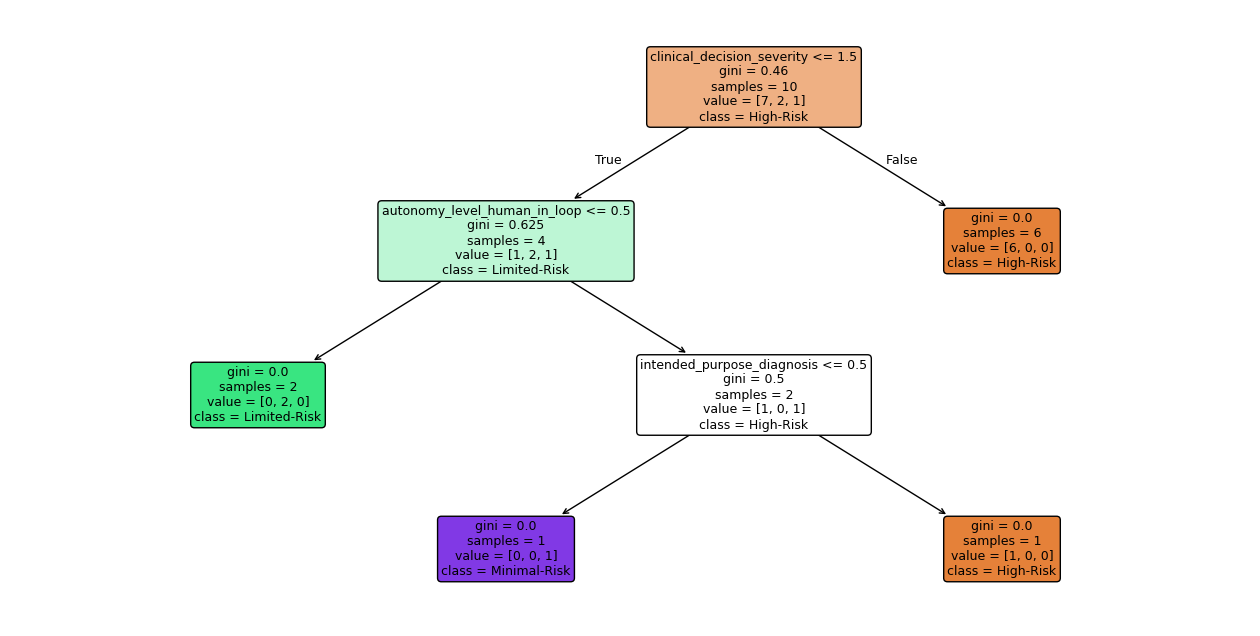

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X, y)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=tree_model.classes_,
          filled=True, rounded=True, fontsize=9)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

